In [1]:
from notebook_setup import add_project_path_to_notebook
add_project_path_to_notebook()

In [2]:
from microtorch.utils.paths import PROJECT_ROOT, SIMULATION_PATH

print("Found project root and path to simulated data at the following locations")
print(f"Project root: {PROJECT_ROOT}")
print(f"Simulation path: {SIMULATION_PATH}")


Found project root and path to simulated data at the following locations
Project root: /Users/scmps8/repos/github.com/microtorch/src/microtorch
Simulation path: /Users/scmps8/repos/github.com/microtorch/simulation_data


In [3]:
import os

#define the path to the simulation data
DATA_PATH = os.path.join(SIMULATION_PATH,"data")

#define the path to the fit output directory
OUTPUT_PATH = os.path.join(PROJECT_ROOT.parent.parent,"outputs")

#find the models where simulation data exists
simulation_data_models = [f for f in os.listdir(DATA_PATH) if not f.startswith(".")]


In [4]:
OUTPUT_PATH

'/Users/scmps8/repos/github.com/microtorch/outputs'

In [ ]:
import glob
import nibabel as nib
from microtorch.utils.helpers import most_recent_output_file
import torch

sim_data = {}
network_type = "hidden_dropout_mlp"

for model in simulation_data_models:    
    #get the simulated data, ground truth parameters and mask for each model and store in a dictionary
    sim_data[model + "_data"] = torch.from_numpy(nib.load(glob.glob(os.path.join(DATA_PATH, model, "*_data.nii.gz"))[0]).get_fdata())
    sim_data[model + "_gt_params"] = torch.from_numpy(nib.load(glob.glob(os.path.join(DATA_PATH, model, "*_params.nii.gz"))[0]).get_fdata())
    sim_data[model + "_mask"] = torch.from_numpy(nib.load(glob.glob(os.path.join(DATA_PATH, model, "*_mask.nii.gz"))[0]).get_fdata())
    
    #get the fitted parameters for each model and store in the dictionary
    try:
        sim_data[model + "_fitted_params"] = torch.from_numpy(nib.load(most_recent_output_file(OUTPUT_PATH, model, network_type)).get_fdata())
        print(f"Fitted parameters found and loaded for model {model}.")
    except:
        print(f"No fitted parameters found for model {model}. Skipping.")       
        simulation_data_models = [m for m in simulation_data_models if m != model]  #remove the model from the list of models 
    
    
    
    

Fitted parameters found and loaded for model Ballt2.
Fitted parameters found and loaded for model Zeppelin.
Fitted parameters found and loaded for model Astrosticks.
Fitted parameters found and loaded for model ZeppelinZeppelin.
Fitted parameters found and loaded for model Stick.
Fitted parameters found and loaded for model SANDI.
Fitted parameters found and loaded for model Msdki.
Fitted parameters found and loaded for model Sphere.
Fitted parameters found and loaded for model VERDICT.
Fitted parameters found and loaded for model Ball.
Fitted parameters found and loaded for model IVIM.
Fitted parameters found and loaded for model Ballt2Ballt2.
No fitted parameters found for model Cylinder. Skipping.
Fitted parameters found and loaded for model BallStick.


In [6]:
#flatten the images

from microtorch.utils.preprocessing import img2voxel

for model in simulation_data_models:
    sim_data[model + "_gt_params_flat"], sim_data[model + "_mask_flat"]= img2voxel(sim_data[model + "_gt_params"], sim_data[model + "_mask"])
    sim_data[model + "_fitted_params_flat"], sim_data[model + "_mask_flat"] = img2voxel(sim_data[model + "_fitted_params"], sim_data[model + "_mask"])

No YAML configuration found for Ballt2 model.
Falling back to parsing model name for compartments: ['Ballt2'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Ballt2
########### Compartments: ['Ballt2']
########### Parameter names: [['D', 'T2']]
########### Parameter ranges: [[[0.001, 3.0], [0.01, 0.5]]]
-----------


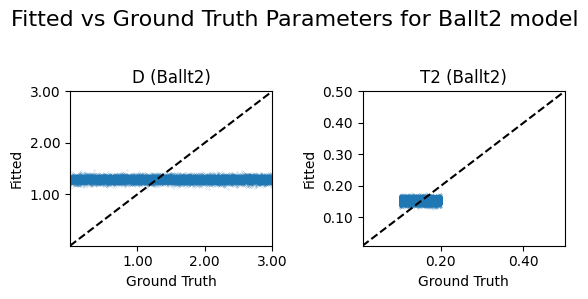

No YAML configuration found for Zeppelin model.
Falling back to parsing model name for compartments: ['Zeppelin'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Zeppelin
########### Compartments: ['Zeppelin']
########### Parameter names: [['Dpar', 'k', 'theta', 'phi']]
########### Parameter ranges: [[[0.001, 3], [0.001, 1.0], [-1.5707963267948966, 1.5707963267948966], [0, 3.141592653589793]]]
-----------


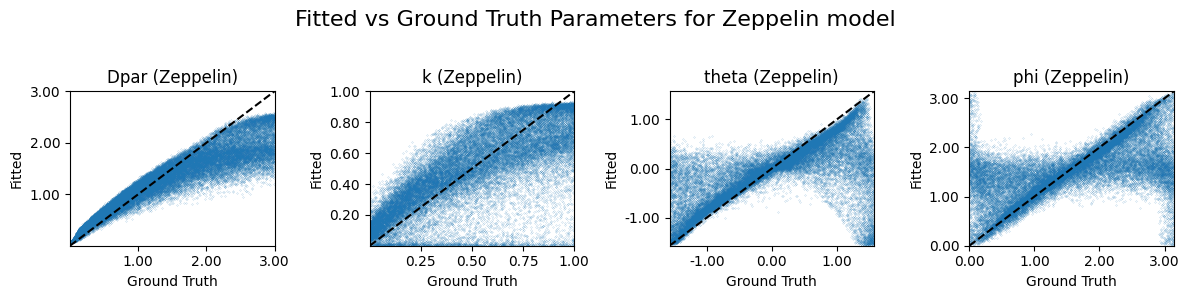

No YAML configuration found for Astrosticks model.
Falling back to parsing model name for compartments: ['Astrosticks'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Astrosticks
########### Compartments: ['Astrosticks']
########### Parameter names: [['D_par']]
########### Parameter ranges: [[[0.5, 3.0]]]
-----------


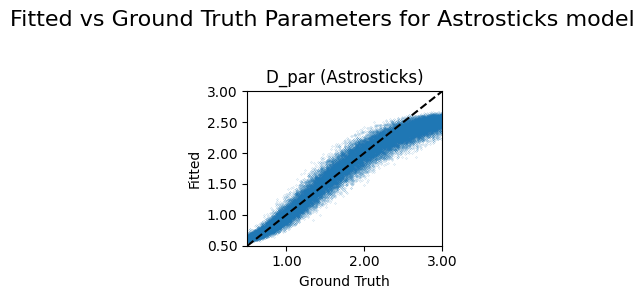

Found YAML configuration for ZeppelinZeppelin model.
Using specified compartments and applying any YAML-defined parameter range overrides.
[[0.001, 3.0], [0.001, 1.0], [0.0, 1.5707963267948966], [0.0, 3.141592653589793]]
[[0.001, 3], [0.001, 1.0], [-1.5707963267948966, 1.5707963267948966], [0, 3.141592653589793]]
[[3.0, 30.0], [0.001, 1.0], [0.0, 1.5707963267948966], [0.0, 3.141592653589793]]
[[0.001, 3], [0.001, 1.0], [-1.5707963267948966, 1.5707963267948966], [0, 3.141592653589793]]
-----------
########### Making model:  ZeppelinZeppelin
########### Compartments: ['Zeppelin', 'Zeppelin']
########### Parameter names: [['Dpar', 'k', 'theta', 'phi'], ['Dpar', 'k', 'theta', 'phi']]
########### Parameter ranges: [[[0.001, 3.0], [0.001, 1.0], [0.0, 1.5707963267948966], [0.0, 3.141592653589793]], [[3.0, 30.0], [0.001, 1.0], [0.0, 1.5707963267948966], [0.0, 3.141592653589793]]]
-----------


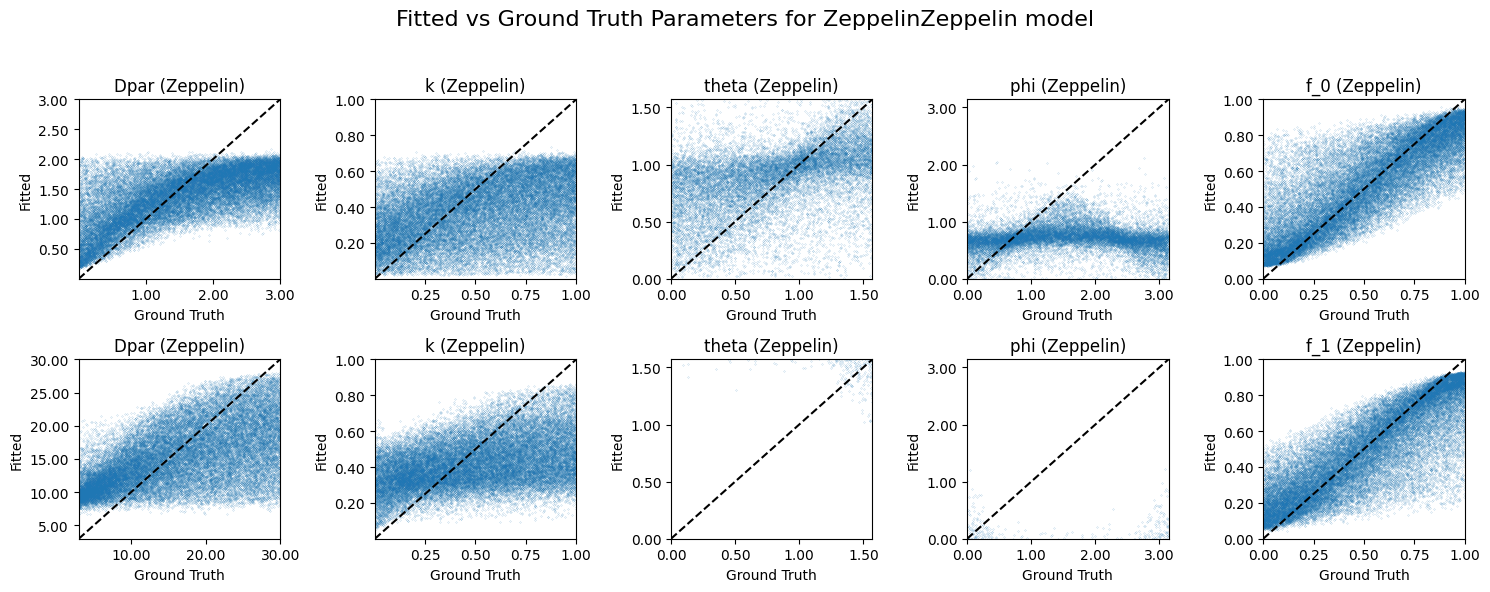

No YAML configuration found for Stick model.
Falling back to parsing model name for compartments: ['Stick'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Stick
########### Compartments: ['Stick']
########### Parameter names: [['Dpar', 'theta', 'phi']]
########### Parameter ranges: [[[0.001, 3], [-1.5707963267948966, 1.5707963267948966], [0, 3.141592653589793]]]
-----------


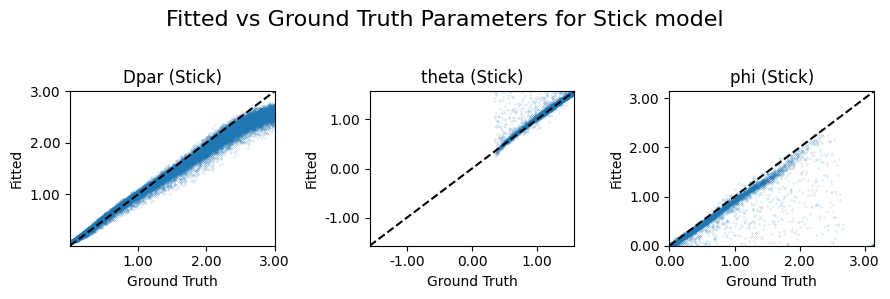

Found YAML configuration for SANDI model.
Using specified compartments and applying any YAML-defined parameter range overrides.
-----------
########### Making model:  SANDI
########### Compartments: ['Ball', 'Sphere', 'Astrosticks']
########### Parameter names: [['D'], ['radius'], ['D_par']]
########### Parameter ranges: [[[0.001, 3]], [[0.001, 15]], [[0.5, 3.0]]]
-----------


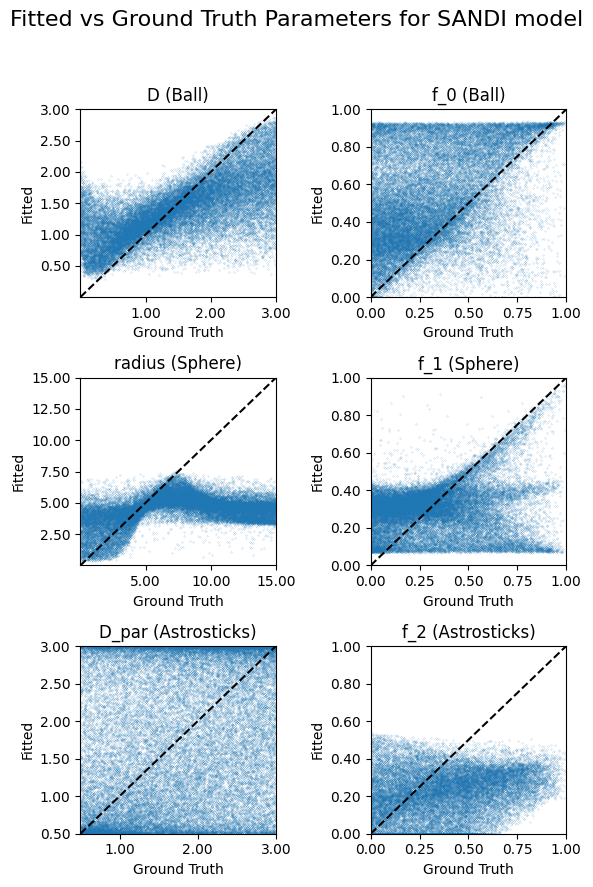

No YAML configuration found for Msdki model.
Falling back to parsing model name for compartments: ['Msdki'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Msdki
########### Compartments: ['Msdki']
########### Parameter names: [['D', 'K']]
########### Parameter ranges: [[[0.001, 3], [0.001, 2]]]
-----------


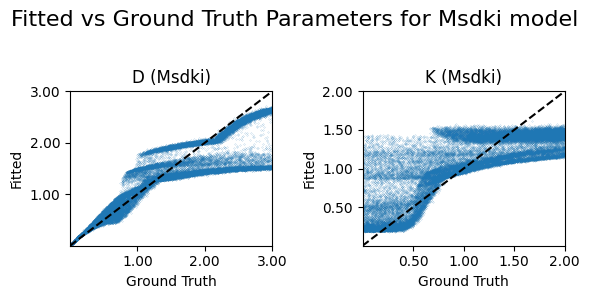

No YAML configuration found for Sphere model.
Falling back to parsing model name for compartments: ['Sphere'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Sphere
########### Compartments: ['Sphere']
########### Parameter names: [['radius']]
########### Parameter ranges: [[[0.001, 15]]]
-----------


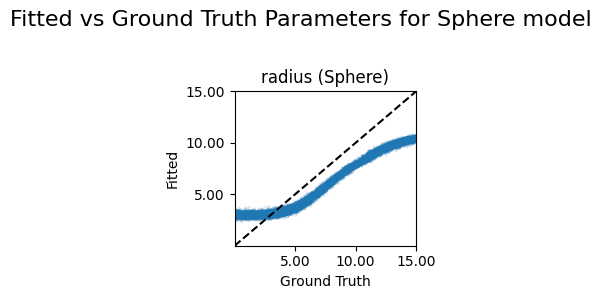

Found YAML configuration for VERDICT model.
Using specified compartments and applying any YAML-defined parameter range overrides.
-----------
########### Making model:  VERDICT
########### Compartments: ['Ball', 'Sphere', 'Astrosticks']
########### Parameter names: [['D'], ['radius'], ['D_par']]
########### Parameter ranges: [[[0.001, 3]], [[0.001, 15]], [[8.0, 8.0]]]
-----------


/var/folders/zl/mns1flqj7bjgsvh9mz33sk2h0000gp/T/ipykernel_48389/2038272115.py:62: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  axis.set_xlim(pr)
/var/folders/zl/mns1flqj7bjgsvh9mz33sk2h0000gp/T/ipykernel_48389/2038272115.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axis.set_ylim(pr)


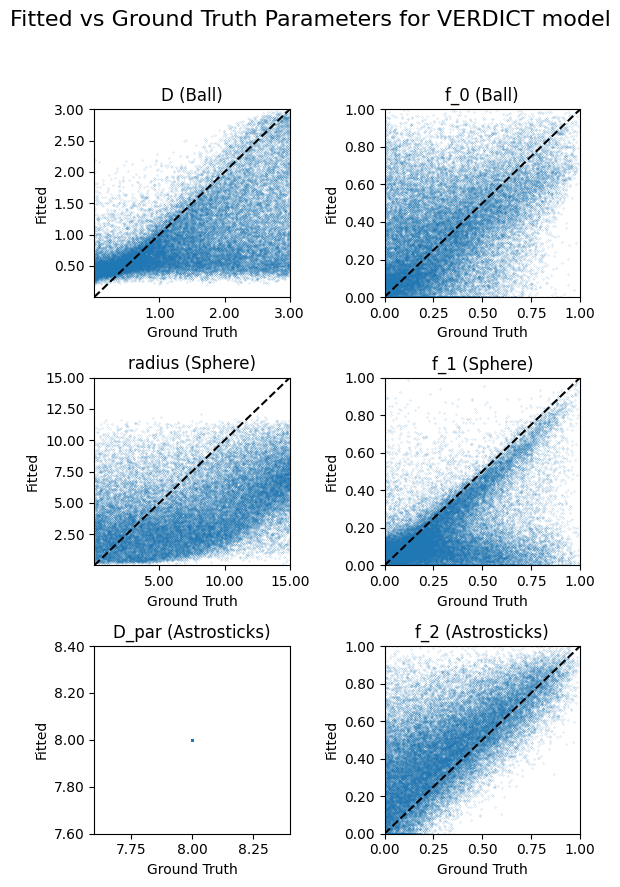

No YAML configuration found for Ball model.
Falling back to parsing model name for compartments: ['Ball'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Ball
########### Compartments: ['Ball']
########### Parameter names: [['D']]
########### Parameter ranges: [[[0.001, 3]]]
-----------


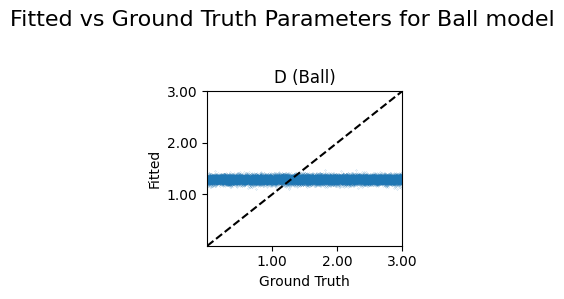

Found YAML configuration for IVIM model.
Using specified compartments and applying any YAML-defined parameter range overrides.
[[0.001, 3.0]]
[[0.001, 3]]
[[3.0, 30.0]]
[[0.001, 3]]
-----------
########### Making model:  IVIM
########### Compartments: ['Ball', 'Ball']
########### Parameter names: [['D'], ['D']]
########### Parameter ranges: [[[0.001, 3.0]], [[3.0, 30.0]]]
-----------


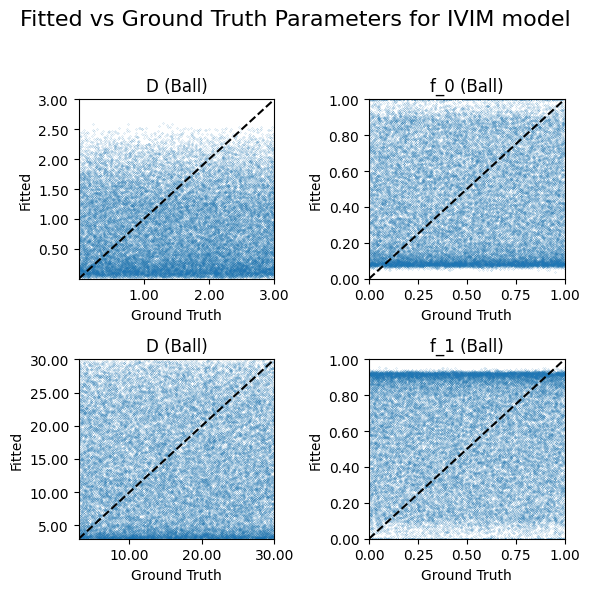

Found YAML configuration for Ballt2Ballt2 model.
Using specified compartments and applying any YAML-defined parameter range overrides.
[[0.001, 3.0], [0.001, 0.08]]
[[0.001, 3.0], [0.01, 0.5]]
[[3.0, 30.0], [0.08, 0.3]]
[[0.001, 3.0], [0.01, 0.5]]
-----------
########### Making model:  Ballt2Ballt2
########### Compartments: ['Ballt2', 'Ballt2']
########### Parameter names: [['D', 'T2'], ['D', 'T2']]
########### Parameter ranges: [[[0.001, 3.0], [0.001, 0.08]], [[3.0, 30.0], [0.08, 0.3]]]
-----------


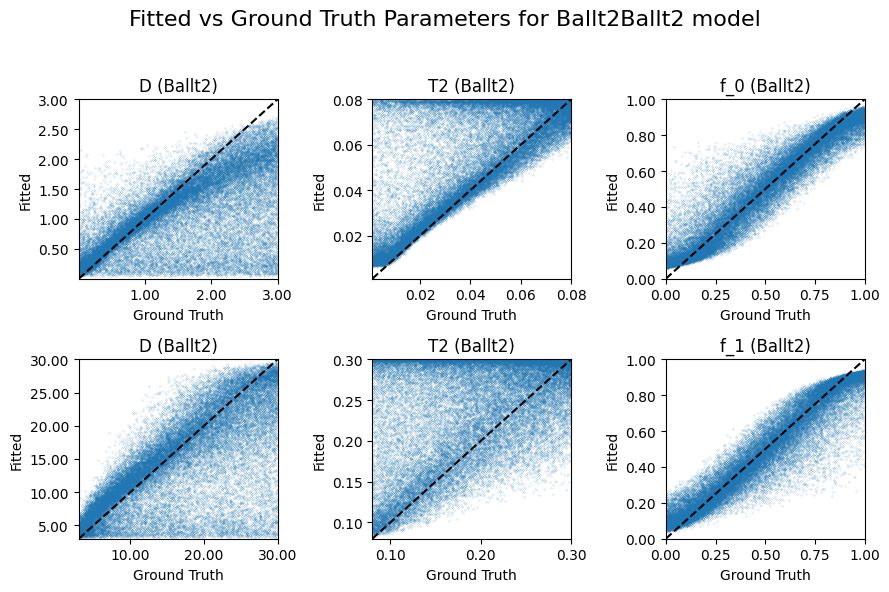

No YAML configuration found for BallStick model.
Falling back to parsing model name for compartments: ['Ball', 'Stick'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  BallStick
########### Compartments: ['Ball', 'Stick']
########### Parameter names: [['D'], ['Dpar', 'theta', 'phi']]
########### Parameter ranges: [[[0.001, 3]], [[0.001, 3], [-1.5707963267948966, 1.5707963267948966], [0, 3.141592653589793]]]
-----------


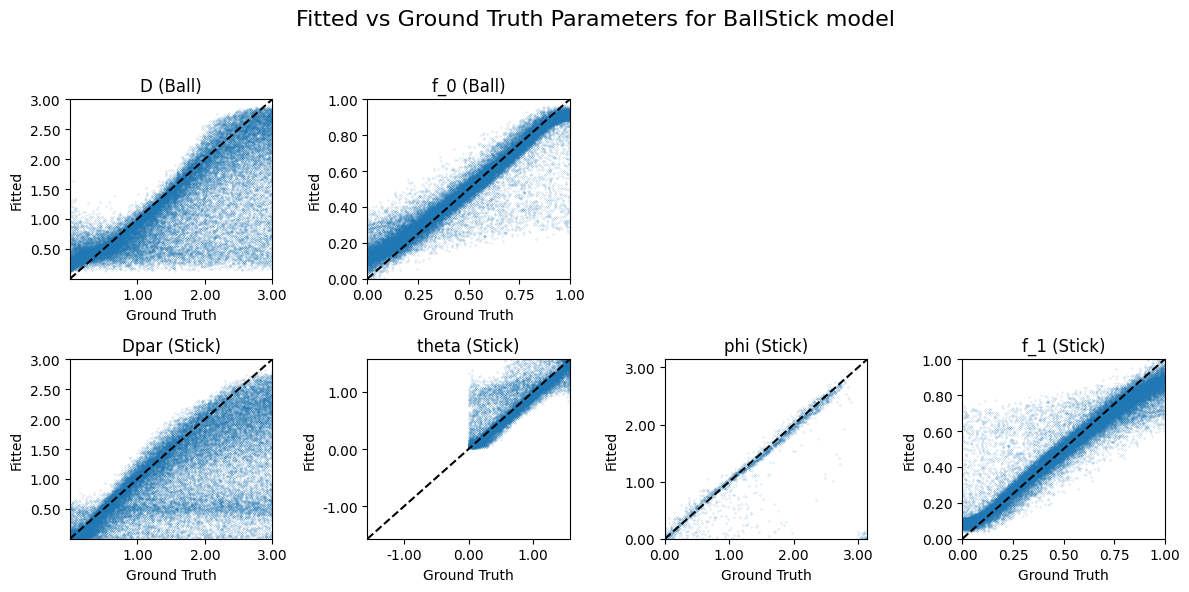

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from microtorch.model_maker import ModelMaker

from matplotlib.ticker import FormatStrFormatter

for model in simulation_data_models:

    modelfunc = ModelMaker(model)

    gt = sim_data[model + "_gt_params_flat"]
    fit = sim_data[model + "_fitted_params_flat"]

    n_maps = gt.shape[1]

    n_compartments = modelfunc.n_compartments

    #count how many params belong to each compartment 
    comp_param_counts = [
        sum(1 for p in range(n_maps) if modelfunc.compartment_indices[p] == c)
        for c in range(n_compartments)
    ]
    max_params = max(comp_param_counts) if comp_param_counts else 1

    fig, ax = plt.subplots(
        n_compartments, max_params,
        figsize=(3 * max_params, 3 * n_compartments),
        squeeze=False
    )

    # plot each compartment row
    for c in range(n_compartments):
        # parameter indices for this compartment (preserves original order)
        p_idxs = [p for p in range(n_maps) if modelfunc.compartment_indices[p] == c]

        for j in range(max_params):
            axis = ax[c, j]

            if j >= len(p_idxs):
                axis.axis("off")
                continue

            p = p_idxs[j]

            axis.plot(gt[:, p], fit[:, p], "o", markersize=0.1)

            axis.set_title(
                f"{modelfunc.parameter_names[p]} "
                f"({modelfunc.compartment_names[modelfunc.compartment_indices[p]]})"
            )
            axis.set_xlabel("Ground Truth")
            axis.set_ylabel("Fitted")
            axis.ticklabel_format(useOffset=False)
            

            # --- identity line + limits ---  
            
            if p < (n_maps - modelfunc.n_fractions) or modelfunc.n_fractions == 1:  # non-fraction parameters for multiple compartments or all parameters if only one compartment
                pr = modelfunc.parameter_ranges[p]
                axis.plot(pr, pr, "k--")
                axis.set_xlim(pr)
                axis.set_ylim(pr)
            else:  # fraction parameters
                if modelfunc.n_fractions > 1:
                    axis.plot([0, 1], [0, 1], "k--")
                    axis.set_xlim(0, 1)
                    axis.set_ylim(0, 1)
                    
            axis.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
            axis.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    plt.suptitle(f"Fitted vs Ground Truth Parameters for {model} model", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Assumed TE values are given in ms and converted to seconds for internal use. If this is not correct, please check your TE values and ensure they are in the correct units.
Calculated gradient strengths from b-values and timing parameters.
Assuming b-values are in ms/μm^2, delta and Delta are in ms. Gradient strengths will be in mT/μm.
No YAML configuration found for Ballt2 model.
Falling back to parsing model name for compartments: ['Ballt2'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Ballt2
########### Compartments: ['Ballt2']
########### Parameter names: [['D', 'T2']]
########### Parameter ranges: [[[0.001, 3.0], [0.01, 0.5]]]
-----------


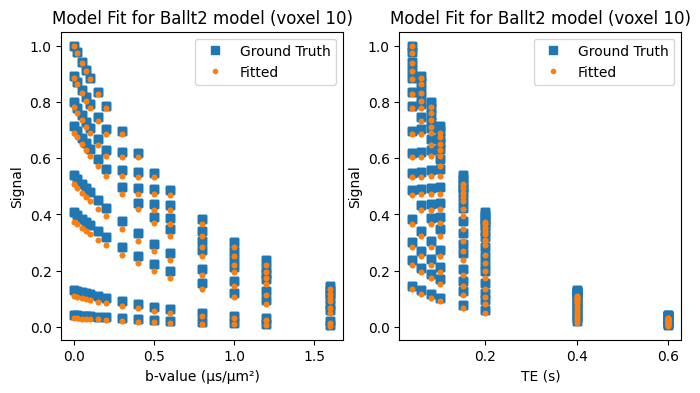

In [8]:
#plot how good the model fit is for a few randomly selected voxels for each model

from microtorch.utils.acquisition_scheme import acquisition_scheme_loader

grad = acquisition_scheme_loader(os.path.join(SIMULATION_PATH,"grad","grad_ivim_T2.txt"))

# for model in simulation_data_models:

model="Ballt2"

modelfunc = ModelMaker(model)

gt = sim_data[model + "_gt_params_flat"]
fit = sim_data[model + "_fitted_params_flat"]

i=10
S_gt = modelfunc(grad, gt[i,:].unsqueeze(0))
S_fit = modelfunc(grad, fit[i,:].unsqueeze(0))


fig, ax = plt.subplots(1,2,figsize=(8,4))

ax[0].plot(grad.bvalues, S_gt[0,:], "s", label="Ground Truth")
ax[0].plot(grad.bvalues, S_fit[0,:], ".", label="Fitted")
ax[0].set_xlabel("b-value (µs/µm²)")
ax[0].set_ylabel("Signal")
ax[0].set_title(f"Model Fit for {model} model (voxel {i})")
ax[0].legend()



ax[1].plot(grad.TE, S_gt[0,:], "s", label="Ground Truth")
ax[1].plot(grad.TE, S_fit[0,:], ".", label="Fitted")
ax[1].set_xlabel("TE (s)")
ax[1].set_ylabel("Signal")
ax[1].set_title(f"Model Fit for {model} model (voxel {i})")
ax[1].legend()


